# 데이터 파악과 조작 연습문제2.

다음 데이터는 깃허브 서비스에서 요일 별 사용자들의 푸시 횟수로, 요일별로 푸시 횟수가 다르다고 한다. 다음 문제들을 위한 코드를 작성하시오.

- 데이터파일 : log_push.csv

### 필요 모듈 임포트

In [2]:
# 필요 모듈
import numpy as np
import pandas as pd

print(f'numpy : {np.__version__}, pandas : {pd.__version__}')

numpy : 2.5.2, pandas : 3.0.5


In [1]:
# 여러 변수 출력 코드
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

### 데이터 수집

In [4]:
data = pd.read_csv('data/log_push.csv')

,log_date,push_count
0,19-02-01,736729
1,19-02-02,511067
2,19-02-03,528724
3,19-02-04,709256
4,19-02-05,740087


### 데이터 기초 정보 파악

: 데이터 일부, 변수, 관측값수, 결측치 여부, 변수의 데이터타입, 기술통계량 등을 확인

In [7]:
data.head()

,log_date,push_count
0,19-02-01,736729
1,19-02-02,511067
2,19-02-03,528724
3,19-02-04,709256
4,19-02-05,740087


In [6]:
data.columns

Index(['log_date', 'push_count'], dtype='str')

In [5]:
data.shape

(348, 2)

In [11]:
data.isna().value_counts()

log_date  push_count
False     False         348
Name: count, dtype: int64

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   log_date    348 non-null    str  
 1   push_count  348 non-null    int64
dtypes: int64(1), str(1)
memory usage: 5.6 KB


In [14]:
data.describe()

,push_count
count,3.480000e+02
mean,8.725456e+05
std,1.522160e+05
min,2.861550e+05
25%,7.229318e+05
50%,9.278870e+05
75%,9.864538e+05
max,1.135921e+06


### 데이터 가공

#### log_date컬럼을 이용하여 요일 컬럼(day_of_week) 생성

- log_date를 날짜형식으로 변경

In [16]:
data['log_date'] = data['log_date'].astype('datetime64[ns]')

In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   log_date    348 non-null    datetime64[ns]
 1   push_count  348 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.6 KB


- log_date를 이용하여 요일 컬럼(day_of_week) 생성

In [19]:
data['day_of_week'] = data['log_date'].dt.dayofweek

In [20]:
data

,log_date,push_count,day_of_week
0,2001-02-19,736729,0
1,2002-02-19,511067,1
2,2003-02-19,528724,2
3,2004-02-19,709256,3
4,2005-02-19,740087,5
...,...,...,...
343,2010-01-20,1000151,2
344,2011-01-20,729593,3
345,2012-01-20,748161,4
346,2013-01-20,1034195,6


- 요일 컬럼의 데이터를 범주형(Category)으로 변경 

In [24]:
data['day_of_week'] = data['day_of_week'].astype('category')

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   log_date     348 non-null    datetime64[ns]
 1   push_count   348 non-null    int64         
 2   day_of_week  348 non-null    category      
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 5.9 KB


### 데이터 탐색 및 시각화

#### 요일별 빈도수

In [28]:
data['day_of_week'].value_counts()

day_of_week
0    50
1    50
3    50
4    50
6    50
2    49
5    49
Name: count, dtype: int64

#### 요일별 push수에 대한 기술통계량

In [30]:
data[data['day_of_week']==0]['push_count'].sum()

np.int64(44273658)

In [32]:
for i in range(7):
    sum = data[data['day_of_week']==i]['push_count'].sum()
    print(f'{i}요일 총 합: {sum}')

0요일 총 합: 44273658
1요일 총 합: 42992049
2요일 총 합: 41550951
3요일 총 합: 43967088
4요일 총 합: 43638321
5요일 총 합: 43257991
6요일 총 합: 43965804


In [33]:
data.groupby('day_of_week')['push_count'].sum()

day_of_week
0    44273658
1    42992049
2    41550951
3    43967088
4    43638321
5    43257991
6    43965804
Name: push_count, dtype: int64

#### 요일별 push수에 대한 박스플롯

day_of_week
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
3    Axes(0.125,0.11;0.775x0.77)
4    Axes(0.125,0.11;0.775x0.77)
5    Axes(0.125,0.11;0.775x0.77)
6    Axes(0.125,0.11;0.775x0.77)
Name: push_count, dtype: object

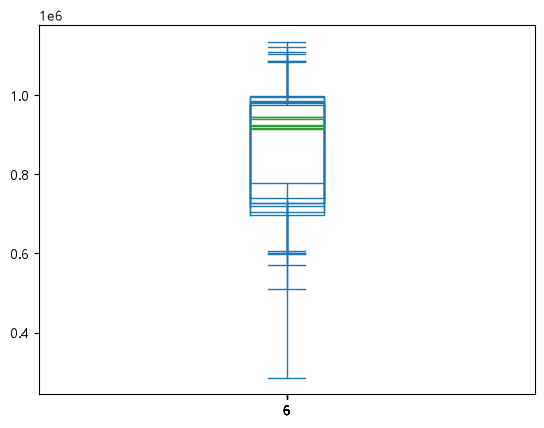

In [38]:
data.groupby('day_of_week')['push_count'].plot.box()

#### push_count에 대한 요일별  히스토그램

day_of_week
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
3    Axes(0.125,0.11;0.775x0.77)
4    Axes(0.125,0.11;0.775x0.77)
5    Axes(0.125,0.11;0.775x0.77)
6    Axes(0.125,0.11;0.775x0.77)
Name: push_count, dtype: object

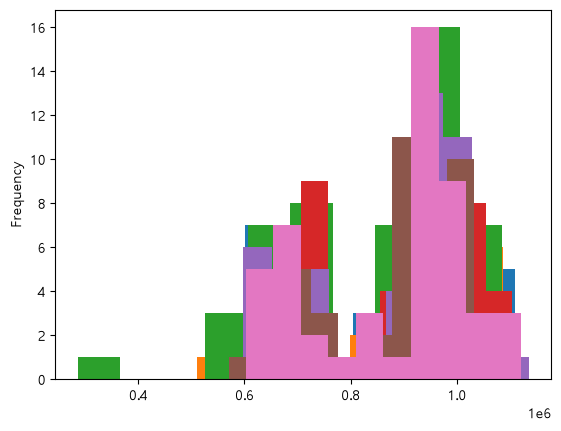

In [37]:
data.groupby('day_of_week')['push_count'].plot.hist()

---